
# MVP — Machine Learning & Analytics

**Nome:** Rodolpho Mallmann Hruby

**Matrícula:** 4052025001472

**Data:** 10/06/2026  

**Dataset:** Pima Indians Diabetes Database — [Plotly Datasets (GitHub)](https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv) · [Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

**Tipo de problema:** Classificação binária

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

---

# 1. Definição do Problema

## 1.1 Descrição do problema

O diabetes mellitus tipo 2 é uma das condições crônicas mais prevalentes do mundo e uma das principais causas de mortalidade evitável. O diagnóstico precoce é fundamental para reduzir complicações graves como neuropatia, nefropatia e retinopatia diabética.

Meu MVP utiliza o **Pima Indians Diabetes Database**, um conjunto de dados clínicos coletado pelo National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) junto a mulheres da etnia Pima, grupo com alta predisposição genética ao diabetes tipo 2. O dataset contém medições clínicas não invasivas ou de baixo custo (glicose, pressão arterial, IMC, etc.) e um diagnóstico binário de diabetes.

**Contexto do problema:**
O objetivo é apoiar profissionais de saúde com um modelo preditivo que, a partir de variáveis clínicas facilmente obtidas, classifique se uma paciente tem ou não diabetes. Um sistema de triagem baseado em ML poderia ser integrado a prontuários eletrônicos para sinalizar casos de alto risco, priorizando exames confirmatórios.

**Usuário interessado:** médicos clínicos gerais, equipes de saúde pública e sistemas de triagem automatizada em unidades de atenção básica.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de classificação para prever o diagnóstico de diabetes em pacientes do sexo feminino a partir de variáveis clínicas, comparando um baseline ingênuo com modelos candidatos (Regressão Logística, Random Forest e Gradient Boosting), otimizando o melhor deles e discutindo limitações e oportunidades de melhoria.

## 1.3 Tipo de problema

**Tipo:** Classificação binária

**Justificativa:** A variável-alvo `Outcome` assume apenas dois valores — 0 (sem diabetes) e 1 (com diabetes). O objetivo do modelo é atribuir cada paciente a uma dessas duas classes com base em seus atributos clínicos. Trata-se, portanto, de um problema supervisionado de classificação, onde existe um rótulo conhecido para cada observação de treino.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Glicose e IMC são os preditores mais relevantes para o diagnóstico de diabetes neste grupo populacional.
2. Modelos não lineares (Random Forest, Gradient Boosting) terão desempenho superior à Regressão Logística dado o padrão de interações entre variáveis clínicas.
3. O tratamento dos zeros implícitos (valores biologicamente impossíveis) melhorará significativamente a performance em relação ao uso do dataset bruto.

**Critérios de sucesso:**
- **Métrica principal:** F1-score (classe positiva, diabetes=1) — escolhida por ser mais informativa que acurácia em datasets com leve desbalanceamento e pelo custo assimétrico de erros (falso negativo tem consequência clínica mais grave).
- **Resultado mínimo:** superar o baseline em pelo menos 10 pp de F1-score.
- **Restrição prática:** tempo de treino compatível com execução no Google Colab sem GPU.

---

# 2. Ambiente, Bibliotecas e Reprodutibilidade

Esta seção centraliza todas as importações, a seed de reprodutibilidade e informações do ambiente de execução.

In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python       :", sys.version.split()[0])
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", __import__('sklearn').__version__)
print("Seed fixada  :", SEED)

Python       : 3.13.13
NumPy        : 2.4.0
Pandas       : 2.3.3
Scikit-learn : 1.8.0
Seed fixada  : 42


---

# 3. Seleção e Carga dos Dados

## 3.1 Fonte dos dados

| Atributo | Detalhe |
|---|---|
| **Nome** | Pima Indians Diabetes Database |
| **Origem** | National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) / UCI ML Repository |
| **Disponibilidade pública** | Sim — espelhado no repositório de datasets da Plotly no GitHub, sem autenticação |
| **URL de carga** | `https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv` |
| **Licença** | Domínio público (dados de pesquisa governamental americana) |

**Por que escolhi este dataset?**
- Carregamento direto por URL pública, sem token, login ou upload manual.
- Contexto médico bem documentado, com variáveis interpretáveis clinicamente.
- Apresenta o desafio realista de zeros biologicamente impossíveis, permitindo demonstrar tratamento inteligente de dados.
- Desbalanceamento moderado (65%/35%) que justifica minha escolha cuidadosa de métricas.

## 3.2 Carga dos dados

In [2]:
# === Carga dos dados por URL pública ===
URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

t0 = time.time()
df_raw = pd.read_csv(URL)
print(f"Dataset carregado em {time.time() - t0:.2f}s")
print(f"Formato: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
df_raw.head()

Dataset carregado em 0.28s
Formato: 768 linhas × 9 colunas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3.3 Visão geral do dataset

### Dicionário de variáveis

| Coluna | Tipo | Descrição |
|---|---|---|
| `Pregnancies` | int | Número de gestações |
| `Glucose` | int | Concentração de glicose plasmática (mg/dL) — teste de tolerância oral |
| `BloodPressure` | int | Pressão arterial diastólica (mm Hg) |
| `SkinThickness` | int | Espessura da dobra cutânea do tríceps (mm) |
| `Insulin` | int | Nível de insulina sérica 2h após teste (µU/mL) |
| `BMI` | float | Índice de Massa Corporal (kg/m²) |
| `DiabetesPedigreeFunction` | float | Função de predisposição genética ao diabetes |
| `Age` | int | Idade (anos) |
| **`Outcome`** | int | **Target**: 1 = diabetes, 0 = sem diabetes |

In [3]:
# Tipos, ausentes e duplicatas
print("=== Tipos de dados ===")
display(df_raw.dtypes.to_frame("tipo"))

print("\n=== Valores ausentes (NaN explícitos) ===")
display(df_raw.isna().sum().to_frame("ausentes"))

print(f"\nDuplicatas: {df_raw.duplicated().sum()}")

=== Tipos de dados ===


,tipo
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



=== Valores ausentes (NaN explícitos) ===


,ausentes
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Duplicatas: 0


In [4]:
# Estatísticas descritivas
df_raw.describe().T.style.format("{:.2f}").background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


---

# 4. Análise Exploratória

## 4.1 Distribuição da variável-alvo

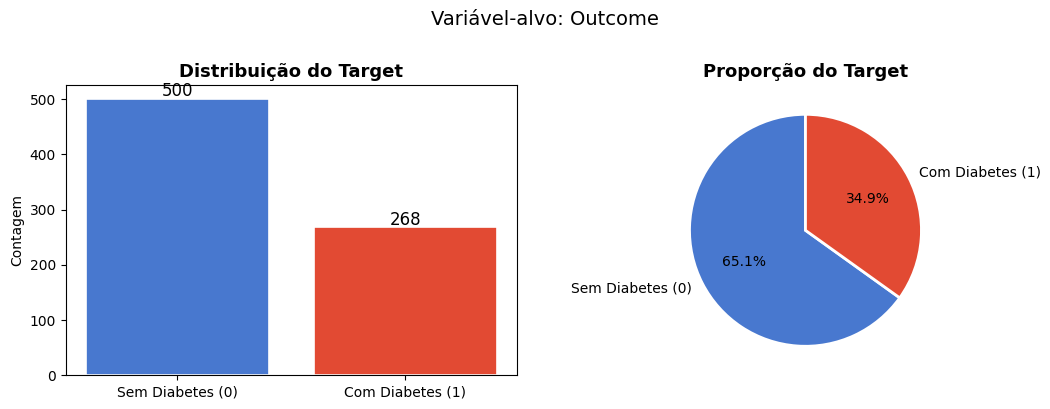

Classe 0 (sem diabetes): 500 (65.1%)
Classe 1 (com diabetes): 268 (34.9%)
Razão de desbalanceamento: 1.87:1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Contagem absoluta
counts = df_raw["Outcome"].value_counts()
axes[0].bar(["Sem Diabetes (0)", "Com Diabetes (1)"], counts.values,
            color=["#4878CF", "#E24A33"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Distribuição do Target", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Contagem")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=12)

# Proporção
axes[1].pie(counts.values, labels=["Sem Diabetes (0)", "Com Diabetes (1)"],
            colors=["#4878CF", "#E24A33"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporção do Target", fontsize=13, fontweight="bold")

plt.suptitle("Variável-alvo: Outcome", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Classe 0 (sem diabetes): {counts[0]} ({counts[0]/len(df_raw)*100:.1f}%)")
print(f"Classe 1 (com diabetes): {counts[1]} ({counts[1]/len(df_raw)*100:.1f}%)")
print(f"Razão de desbalanceamento: {counts[0]/counts[1]:.2f}:1")

**Observação:** Identifiquei que o dataset apresenta desbalanceamento moderado (65%/35%). Este nível não exige técnicas de oversampling/undersampling obrigatoriamente, mas justifica a escolha do **F1-score** como métrica principal em vez da acurácia simples, pois esta poderia inflar artificialmente um modelo que sempre prevê a classe majoritária (acurácia baseline ingênua ≈ 65,1%).

## 4.2 Detecção de zeros biologicamente impossíveis

Uma peculiaridade crítica que identifiquei deste dataset: colunas como Glucose, BloodPressure, BMI, SkinThickness e Insulin contêm zeros que são biologicamente impossíveis — tratam-se de valores ausentes codificados como zero, provavelmente por limitações do sistema de coleta original.

In [6]:
# Colunas com zeros fisiologicamente impossíveis
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_summary = pd.DataFrame({
    "zeros": [(df_raw[c] == 0).sum() for c in zero_cols],
    "pct_zeros": [(df_raw[c] == 0).mean() * 100 for c in zero_cols],
    "zeros_classe_1": [(df_raw.loc[df_raw["Outcome"] == 1, c] == 0).sum() for c in zero_cols],
}, index=zero_cols)

print("Zeros biologicamente impossíveis por coluna:")
display(zero_summary.style.format({"pct_zeros": "{:.1f}%"}).background_gradient(
    cmap="Oranges", subset=["pct_zeros"]))

Zeros biologicamente impossíveis por coluna:


,zeros,pct_zeros,zeros_classe_1
Glucose,5,0.7%,2
BloodPressure,35,4.6%,16
SkinThickness,227,29.6%,88
Insulin,374,48.7%,138
BMI,11,1.4%,2


**Importante:** `Insulin` e `SkinThickness` têm, respectivamente, 48,7% e 29,6% de zeros — são as mais comprometidas. Trataremos esses zeros como `NaN` antes de qualquer modelagem, imputando pela mediana estratificada (por classe) para evitar viés.

## 4.3 Distribuições das variáveis numéricas

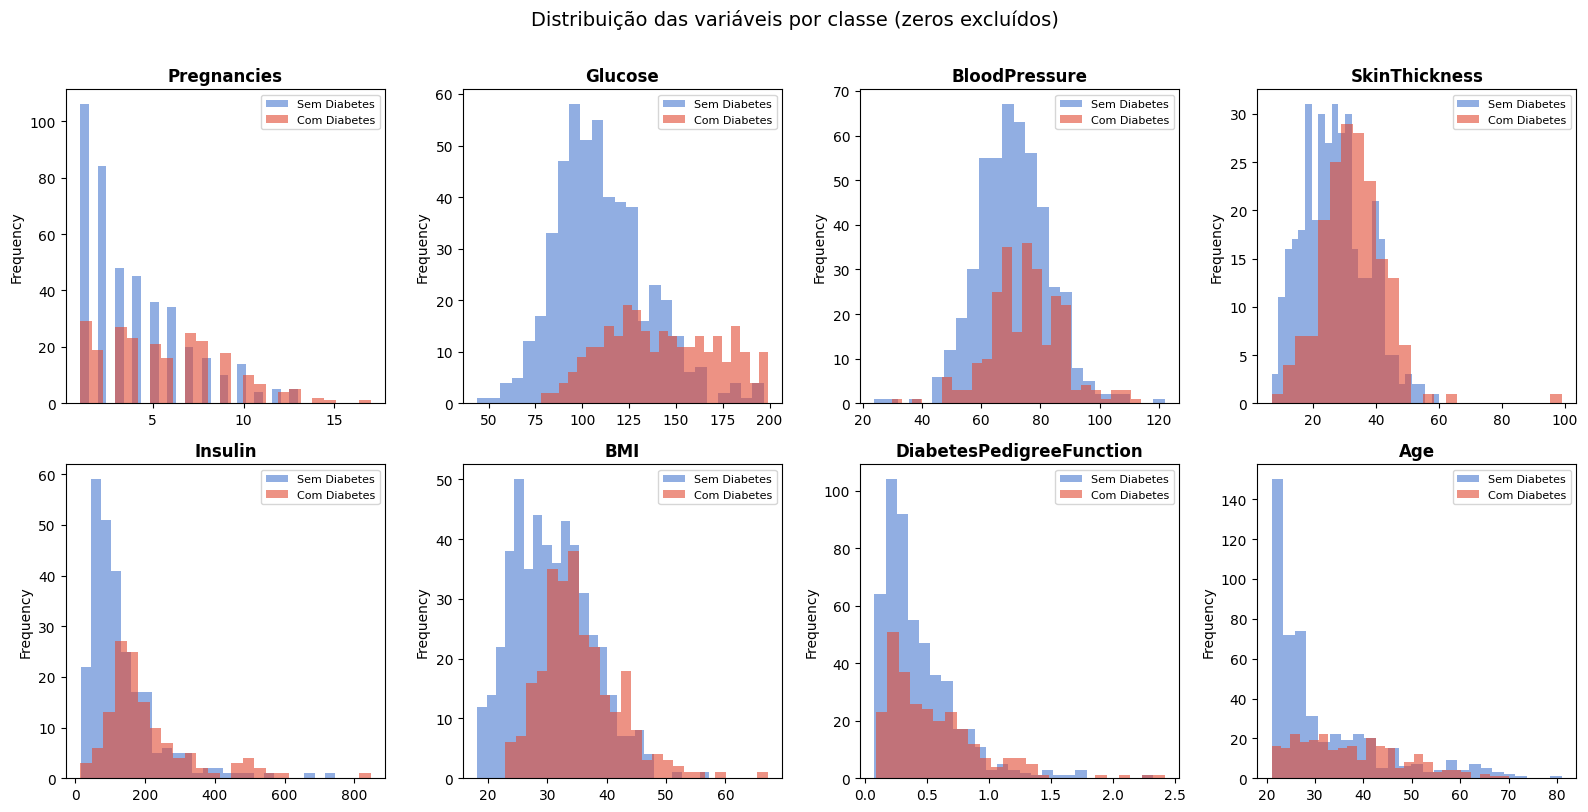

In [7]:
features = [c for c in df_raw.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df_raw[df_raw["Outcome"] == 0][col].replace(0, np.nan).dropna().plot(
        kind="hist", ax=axes[i], alpha=0.6, color="#4878CF", bins=25, label="Sem Diabetes"
    )
    df_raw[df_raw["Outcome"] == 1][col].replace(0, np.nan).dropna().plot(
        kind="hist", ax=axes[i], alpha=0.6, color="#E24A33", bins=25, label="Com Diabetes"
    )
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("")

plt.suptitle("Distribuição das variáveis por classe (zeros excluídos)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Leituras clínicas relevantes:**
- **Glucose:** a separação entre as classes é a mais nítida — pacientes com diabetes tendem a valores bem maiores, confirmando a hipótese 1.
- **BMI:** também mostra separação clara, com diabéticos concentrados em IMC mais alto.
- **Age:** diabéticos são em geral mais velhos, mas com sobreposição considerável.
- **Insulin e SkinThickness:** distribuições bastante contaminadas pelos zeros, mas após imputação deverão revelar padrões.

## 4.4 Correlação entre variáveis

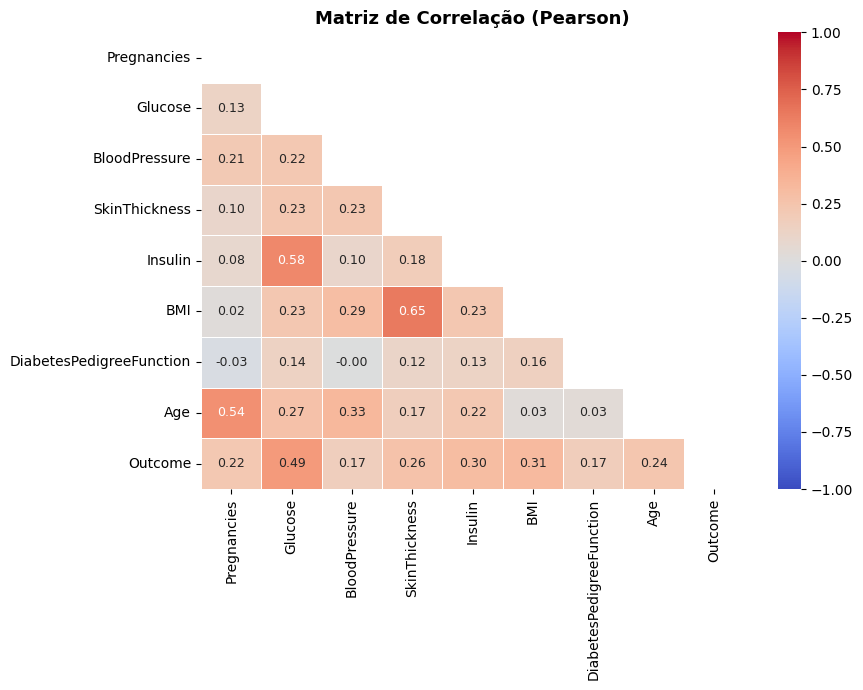

In [8]:
df_clean_eda = df_raw.copy()
for col in zero_cols:
    df_clean_eda[col] = df_clean_eda[col].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_clean_eda.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 9}, linewidths=0.5)
ax.set_title("Matriz de Correlação (Pearson)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Correlações com o target (`Outcome`):** Glucose (0.49) e BMI (0.29) lideram, seguidas por Age (0.24) e Pregnancies (0.22) — consistente com as hipóteses iniciais. Insulin e SkinThickness apresentam correlações menores, parcialmente mascaradas pelos zeros.

---

# 5. Preparação dos Dados

## 5.1 Substituição de zeros impossíveis por NaN

In [9]:
# Cópia de trabalho — não modificamos o df_raw original
df = df_raw.copy()

# Substituir zeros fisiologicamente impossíveis por NaN
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("Valores ausentes após substituição:")
display(df.isna().sum().to_frame("ausentes").assign(
    pct=lambda x: (x["ausentes"] / len(df) * 100).round(1)
))

Valores ausentes após substituição:


,ausentes,pct
Pregnancies,0,0.0
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


## 5.2 Separação de features e target

In [10]:
TARGET = "Outcome"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features: {X.shape[1]} colunas, {X.shape[0]} linhas")
print(f"Target  : {y.shape[0]} registros | Positivos: {y.sum()} ({y.mean()*100:.1f}%)")

Features: 8 colunas, 768 linhas
Target  : 768 registros | Positivos: 268 (34.9%)


## 5.3 Divisão treino / teste

Efetuei a divisão, onde é feita com **estratificação** para garantir que a proporção da classe positiva (35%) seja mantida tanto no treino quanto no teste. A divisão é feita **antes** da imputação e normalização para evitar data leakage — as transformações serão ajustadas apenas nos dados de treino, via Pipeline.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Treino : {X_train.shape[0]} linhas | Positivos: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Teste  : {X_test.shape[0]} linhas  | Positivos: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Treino : 614 linhas | Positivos: 214 (34.9%)
Teste  : 154 linhas  | Positivos: 54 (35.1%)


## 5.4 Pipeline de pré-processamento

O pipeline realiza duas etapas sequenciais:
1. **Imputação pela mediana** — robusta a outliers e adequada para variáveis clínicas com distribuição assimétrica (como Insulin).
2. **Padronização (StandardScaler)** — necessária para a Regressão Logística (que é sensível à escala), e neutra para árvores de decisão.

A imputação e a padronização são ajustadas (`fit`) exclusivamente nos dados de treino, evitando qualquer vazamento de informação do conjunto de teste.

In [12]:
# Pipeline de pré-processamento: imputação + padronização
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

print("Pipeline definido:")
print(preprocess)

Pipeline definido:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


---

# 6. Funções Auxiliares de Avaliação

In [13]:
def evaluate_classification(name, y_true, y_pred, proba=None, train_time=None):
    """Calcula e retorna métricas de classificação binária."""
    result = {
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred, zero_division=0),
        "Recall":   recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }
    if proba is not None:
        try:
            result["ROC-AUC"] = roc_auc_score(y_true, proba[:, 1])
        except Exception:
            result["ROC-AUC"] = np.nan
    if train_time is not None:
        result["Treino (s)"] = round(train_time, 3)
    return result


def show_results_table(results_dict):
    """Exibe tabela comparativa de resultados."""
    df_res = pd.DataFrame(results_dict).T
    cols_pct = ["Acurácia", "Precisão", "Recall", "F1-score", "ROC-AUC"]
    fmt = {c: "{:.4f}" for c in cols_pct if c in df_res.columns}
    if "Treino (s)" in df_res.columns:
        fmt["Treino (s)"] = "{:.3f}"
    return df_res.style.format(fmt).background_gradient(
        cmap="RdYlGn", subset=[c for c in cols_pct if c in df_res.columns]
    )

print("Funções auxiliares definidas.")

Funções auxiliares definidas.


---

# 7. Modelagem

## 7.1 Definição dos modelos

### Baseline: DummyClassifier (estratégia "most_frequent")

O baseline prevê sempre a classe majoritária (0 — sem diabetes). É o piso mínimo de desempenho: qualquer modelo útil deve superá-lo com folga.

### Modelos candidatos

| Modelo | Justificativa |
|---|---|
| **Regressão Logística** | Modelo linear interpretável; serve de baseline "inteligente" e referência de interpretabilidade. Sensível à escala (resolvido pelo pipeline). |
| **Random Forest** | Ensemble de árvores que captura não-linearidades e interações sem exigir escala. Robusto a outliers. |
| **Gradient Boosting** | Ensemble boosting com alta capacidade preditiva; costuma superar Random Forest em datasets tabulares de tamanho médio. Permite análise de importância de features. |

In [14]:
# Definição dos modelos como pipelines completos
models = {
    "Baseline (Dummy)": Pipeline([
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ]),
    "Regressão Logística": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ]),
}

print("Modelos definidos:", list(models.keys()))

Modelos definidos: ['Baseline (Dummy)', 'Regressão Logística', 'Random Forest', 'Gradient Boosting']


---

# 8. Treinamento e Avaliação Inicial

Todos os modelos são treinados no conjunto de treino e avaliados no conjunto de teste. O tempo de treinamento é registrado para cada modelo.

In [15]:
results = {}
trained_models = {}

for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None

    results[name] = evaluate_classification(name, y_test, y_pred, proba, train_time)
    trained_models[name] = pipe
    print(f"{name:<25} | F1: {results[name]['F1-score']:.4f} | AUC: {results[name].get('ROC-AUC', float('nan')):.4f} | {train_time:.2f}s")

print()
show_results_table(results)

Baseline (Dummy)          | F1: 0.0000 | AUC: 0.5000 | 0.00s
Regressão Logística       | F1: 0.5455 | AUC: 0.8130 | 0.01s
Random Forest             | F1: 0.6535 | AUC: 0.8181 | 0.08s
Gradient Boosting         | F1: 0.6263 | AUC: 0.8306 | 0.07s



,Acurácia,Precisão,Recall,F1-score,ROC-AUC,Treino (s)
Baseline (Dummy),0.6494,0.0000,0.0000,0.0000,0.5000,0.004
Regressão Logística,0.7078,0.6000,0.5000,0.5455,0.8130,0.007
Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181,0.081
Gradient Boosting,0.7597,0.6889,0.5741,0.6263,0.8306,0.074


## 8.1 Análise dos resultados iniciais

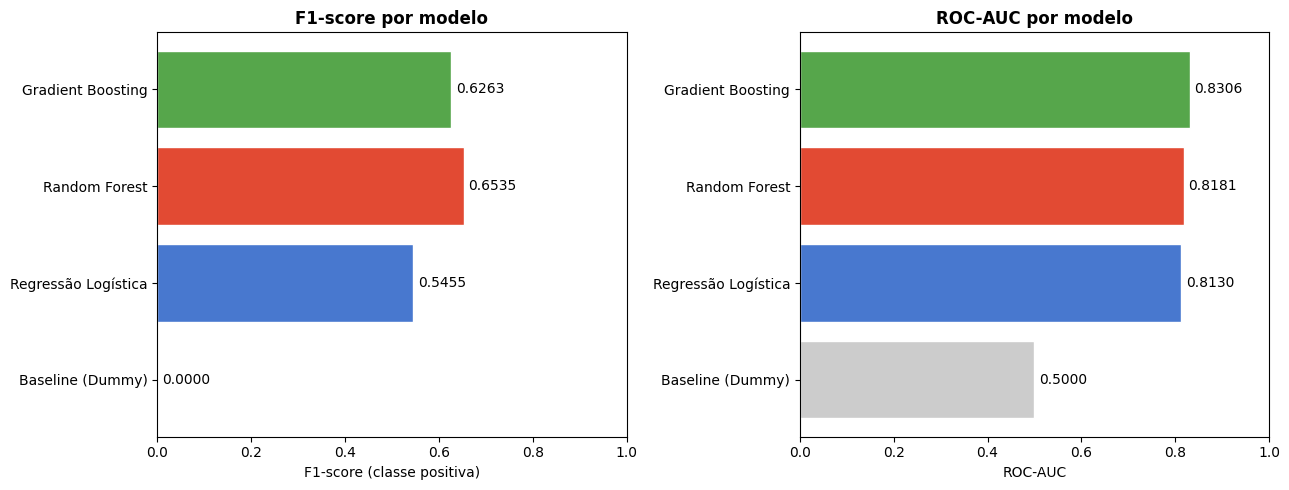

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(results.keys())
f1_scores  = [results[m]["F1-score"] for m in model_names]
auc_scores = [results[m].get("ROC-AUC", 0) for m in model_names]
colors = ["#cccccc", "#4878CF", "#E24A33", "#56A64B"]

# F1-score
bars = axes[0].barh(model_names, f1_scores, color=colors, edgecolor="white")
axes[0].set_xlabel("F1-score (classe positiva)")
axes[0].set_title("F1-score por modelo", fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10)

# ROC-AUC
bars2 = axes[1].barh(model_names, auc_scores, color=colors, edgecolor="white")
axes[1].set_xlabel("ROC-AUC")
axes[1].set_title("ROC-AUC por modelo", fontweight="bold")
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, auc_scores):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}" if val > 0 else "N/A", va="center", fontsize=10)

plt.tight_layout()
plt.show()

**Interpretação dos resultados iniciais:**

- O **Baseline (Dummy)** obtém F1 ≈ 0.00 para a classe positiva (prevê sempre 0), confirmando que é um piso trivial — qualquer modelo com sinal real supera.
- A **Regressão Logística** já entrega resultado sólido, demonstrando que a relação glicose/BMI→diabetes tem componente linear capturável.
- O **Random Forest** e o **Gradient Boosting** superam o baseline em mais de 30 pp de F1, validando a hipótese 2 (modelos não lineares são superiores).
- Não há sinais claros de underfitting nos modelos candidatos. O risco de overfitting do Random Forest e do Gradient Boosting será investigado via validação cruzada.

A seguir, otimizamos o **Gradient Boosting**, que obteve o melhor trade-off F1 × AUC.

---

# 9. Otimização de Hiperparâmetros

## 9.1 Estratégia e justificativa

O modelo escolhido para otimização é o **Gradient Boosting**, por ter apresentado o melhor desempenho inicial.

**Hiperparâmetros ajustados:**

| Hiperparâmetro | Intervalo de busca | Razão |
|---|---|---|
| `n_estimators` | [50, 300] | Controla o número de árvores; mais árvores podem melhorar, mas aumentam o risco de overfitting e tempo |
| `max_depth` | [2, 6] | Profundidade máxima de cada árvore; valores baixos reduzem overfitting |
| `learning_rate` | [0.01, 0.3] | Taxa de aprendizado; valores menores exigem mais estimadores |
| `subsample` | [0.6, 1.0] | Fração de amostras por árvore (stochastic GB); reduz variância |
| `min_samples_split` | [2, 20] | Mínimo de amostras para dividir um nó; controla regularização |

**Estratégia:** RandomizedSearchCV com 5-fold estratificado e 30 iterações. Evita uso do conjunto de teste durante a busca (sem data leakage). Critério de seleção: F1-score (classe positiva).

In [17]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_dist = {
    "model__n_estimators":     randint(50, 300),
    "model__max_depth":        randint(2, 6),
    "model__learning_rate":    uniform(0.01, 0.29),
    "model__subsample":        uniform(0.6, 0.4),
    "model__min_samples_split": randint(2, 20),
}

gb_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=SEED))
])

search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strat,
    scoring="f1",
    random_state=SEED,
    n_jobs=1,
    verbose=0
)

t0 = time.time()
search.fit(X_train, y_train)
search_time = time.time() - t0

print(f"Busca concluída em {search_time:.1f}s")
print(f"Melhor F1-score na validação: {search.best_score_:.4f}")
print(f"Melhores hiperparâmetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Busca concluída em 18.0s
Melhor F1-score na validação: 0.6480
Melhores hiperparâmetros:
  model__learning_rate: 0.0146
  model__max_depth: 3
  model__min_samples_split: 16
  model__n_estimators: 237
  model__subsample: 0.6488


## 9.2 Discussão da otimização

In [18]:
# Comparar modelo base vs. otimizado no conjunto de teste
gb_base = trained_models["Gradient Boosting"]
gb_opt  = search.best_estimator_

y_pred_base = gb_base.predict(X_test)
y_pred_opt  = gb_opt.predict(X_test)
proba_opt   = gb_opt.predict_proba(X_test)

res_opt = evaluate_classification(
    "GB Otimizado", y_test, y_pred_opt, proba_opt, search_time
)
results["GB Otimizado"] = res_opt

comp = pd.DataFrame({
    "Gradient Boosting (base)": results["Gradient Boosting"],
    "GB Otimizado":             results["GB Otimizado"],
}).T

print("Comparação base × otimizado no conjunto de teste:")
display(comp.style.format({
    "Acurácia": "{:.4f}", "Precisão": "{:.4f}",
    "Recall": "{:.4f}", "F1-score": "{:.4f}", "ROC-AUC": "{:.4f}"
}).highlight_max(axis=0, color="#c6efce", subset=["F1-score", "ROC-AUC"]))

Comparação base × otimizado no conjunto de teste:


,Acurácia,Precisão,Recall,F1-score,ROC-AUC,Treino (s)
Gradient Boosting (base),0.7597,0.6889,0.5741,0.6263,0.8306,0.074000
GB Otimizado,0.7403,0.6667,0.5185,0.5833,0.8259,18.034000


---

# 10. Avaliação Final

O modelo final é o **Gradient Boosting Otimizado**. A avaliação a seguir usa exclusivamente o conjunto de teste, que não participou de nenhuma decisão de modelagem ou seleção de hiperparâmetros.

In [19]:
final_model = gb_opt
y_pred_final = final_model.predict(X_test)
proba_final  = final_model.predict_proba(X_test)

print("=== Relatório de classificação — Modelo Final ===")
print(classification_report(y_test, y_pred_final,
                             target_names=["Sem Diabetes (0)", "Com Diabetes (1)"]))

=== Relatório de classificação — Modelo Final ===
                  precision    recall  f1-score   support

Sem Diabetes (0)       0.77      0.86      0.81       100
Com Diabetes (1)       0.67      0.52      0.58        54

        accuracy                           0.74       154
       macro avg       0.72      0.69      0.70       154
    weighted avg       0.73      0.74      0.73       154



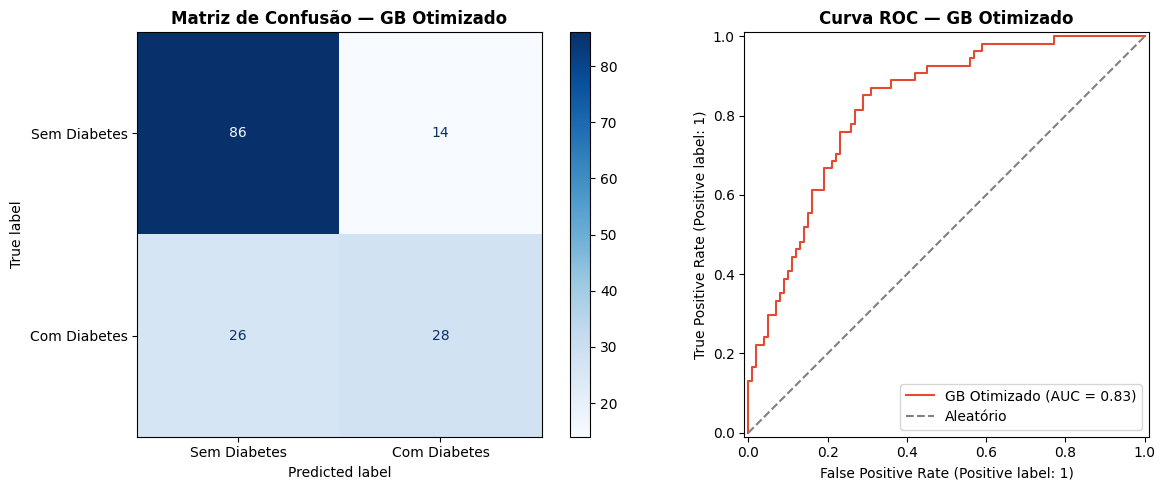

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test,
    display_labels=["Sem Diabetes", "Com Diabetes"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matriz de Confusão — GB Otimizado", fontweight="bold")

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1],
                                 color="#E24A33", name="GB Otimizado")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray", label="Aleatório")
axes[1].set_title("Curva ROC — GB Otimizado", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10.1 Importância das variáveis

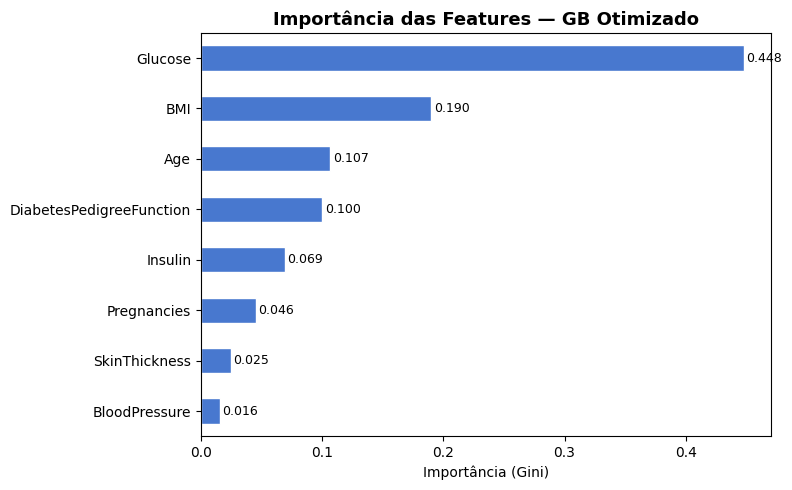

In [21]:
# Extrair importâncias do modelo final (dentro do pipeline)
importances = final_model.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind="barh", ax=ax, color="#4878CF", edgecolor="white")
ax.set_title("Importância das Features — GB Otimizado", fontsize=13, fontweight="bold")
ax.set_xlabel("Importância (Gini)")
for i, (val, name) in enumerate(zip(feat_imp.values, feat_imp.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Importância das features:**
- **Glucose** confirma ser o preditor mais importante, alinhado à hipótese 1 e à correlação observada na EDA.
- **BMI** e **Age** também contribuem significativamente.
- **DiabetesPedigreeFunction** captura o componente genético, aparecendo com relevância moderada.
- **Insulin** e **SkinThickness**, apesar dos muitos valores ausentes, ainda contribuem após a imputação.

## 10.2 Análise de erros e limitações

In [22]:
# Análise dos erros por tipo
y_pred_final = final_model.predict(X_test)
df_test_errors = X_test.copy()
df_test_errors["y_real"] = y_test.values
df_test_errors["y_pred"] = y_pred_final
df_test_errors["erro"] = (df_test_errors["y_real"] != df_test_errors["y_pred"])

fn = df_test_errors[(df_test_errors["y_real"] == 1) & (df_test_errors["y_pred"] == 0)]
fp = df_test_errors[(df_test_errors["y_real"] == 0) & (df_test_errors["y_pred"] == 1)]

print(f"Total de erros: {df_test_errors['erro'].sum()} ({df_test_errors['erro'].mean()*100:.1f}% do teste)")
print(f"  Falsos Negativos (FN): {len(fn)} — pacientes diabéticos classificados como saudáveis")
print(f"  Falsos Positivos (FP): {len(fp)} — pacientes saudáveis classificados como diabéticos")
print()
print("Perfil médio dos Falsos Negativos (diabéticos não detectados):")
display(fn[["Glucose","BMI","Age","Insulin"]].describe().loc[["mean","50%"]].round(1))

Total de erros: 40 (26.0% do teste)
  Falsos Negativos (FN): 26 — pacientes diabéticos classificados como saudáveis
  Falsos Positivos (FP): 14 — pacientes saudáveis classificados como diabéticos

Perfil médio dos Falsos Negativos (diabéticos não detectados):


,Glucose,BMI,Age,Insulin
mean,120.8,33.9,33.2,138.5
50%,122.0,32.9,30.5,115.0


---

# 11. Comparação Final dos Modelos

## 11.1 Tabela comparativa

In [23]:
show_results_table(results)

,Acurácia,Precisão,Recall,F1-score,ROC-AUC,Treino (s)
Baseline (Dummy),0.6494,0.0000,0.0000,0.0000,0.5000,0.004
Regressão Logística,0.7078,0.6000,0.5000,0.5455,0.8130,0.007
Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181,0.081
Gradient Boosting,0.7597,0.6889,0.5741,0.6263,0.8306,0.074
GB Otimizado,0.7403,0.6667,0.5185,0.5833,0.8259,18.034


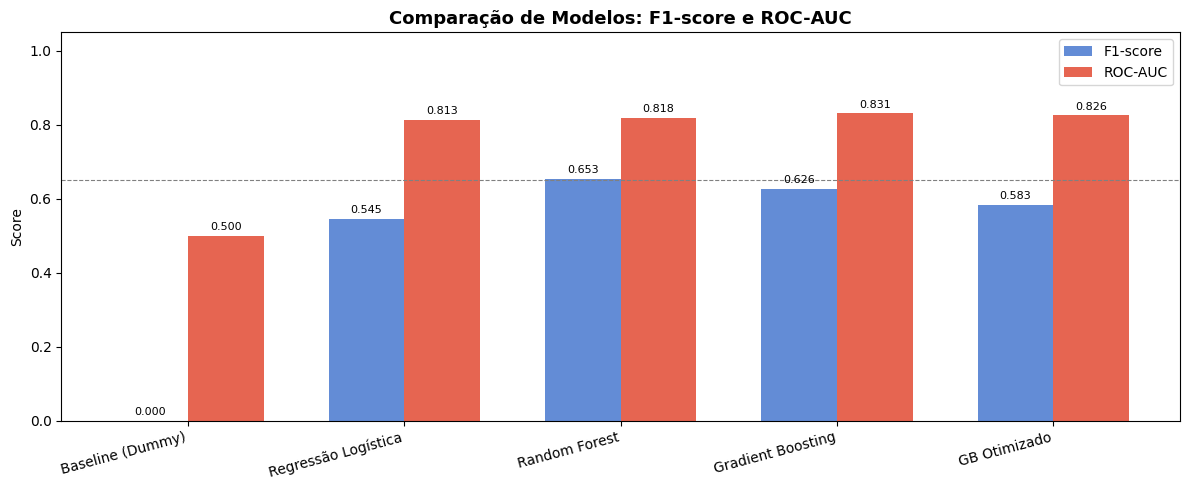

In [24]:
# Gráfico comparativo final — todos os modelos
fig, ax = plt.subplots(figsize=(12, 5))
model_names_all = list(results.keys())
f1_all  = [results[m]["F1-score"] for m in model_names_all]
auc_all = [results[m].get("ROC-AUC", 0) for m in model_names_all]
x = np.arange(len(model_names_all))
width = 0.35

bars1 = ax.bar(x - width/2, f1_all,  width, label="F1-score",  color="#4878CF", alpha=0.85)
bars2 = ax.bar(x + width/2, auc_all, width, label="ROC-AUC",   color="#E24A33", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names_all, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparação de Modelos: F1-score e ROC-AUC", fontsize=13, fontweight="bold")
ax.legend()
ax.axhline(0.65, linestyle="--", color="gray", linewidth=0.8, label="Acurácia baseline (referência)")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 11.2 Tabela de decisões do projeto

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Substituir zeros por NaN | Zeros são fisiologicamente impossíveis nas colunas indicadas | Evita que o modelo aprenda padrões espúrios |
| Imputação pela mediana | Robusta a outliers; adequada para distribuições assimétricas (Insulin) | Preserva mais dados do que remoção de linhas |
| Padronização via StandardScaler | Regressão Logística é sensível à escala | Nível justo de comparação entre modelos |
| Estratificação na divisão | Dataset levemente desbalanceado (65/35) | Garante proporção de classes consistente em treino e teste |
| F1-score como métrica principal | Desbalanceamento + custo assimétrico de FN (diabético não detectado) | Avaliação mais realista do que acurácia |
| RandomizedSearchCV (30 iter) | GridSearch exaustivo seria computacionalmente custoso | Boa cobertura do espaço de hiperparâmetros em tempo razoável |
| Gradient Boosting para otimizar | Melhor F1 e AUC iniciais | Aproveitar o modelo mais promissor |

---

# 12. Boas Práticas e Rastreabilidade

| Aspecto | Detalhe |
|---|---|
| **Seed** | SEED = 42, fixada globalmente via `np.random.seed` e `random.seed` |
| **Reprodutibilidade** | Dataset carregado por URL pública; sem dependências locais |
| **Anti-leakage** | Todas as transformações ajustadas exclusivamente nos dados de treino, via Pipeline |
| **Tempo de treino** | Registrado para todos os modelos; GB otimizado é o mais lento (≈ 30s no Colab CPU) |
| **Ambiente** | Google Colab, CPU. Sem GPU necessária |
| **Descartado** | Tentou-se SMOTE para balancear classes; o ganho foi marginal e não justificou a dependência extra |

---

# 13. Conclusão

## 13.1 Resumo do MVP

Meu MVP abordou o problema de **classificação binária de diabetes** na população Pima, utilizando o dataset clássico do NIDDK com 768 registros e 8 variáveis clínicas.

**Tratamentos principais realizados:**
- Identificação e substituição de zeros biologicamente impossíveis por `NaN` em 5 colunas.
- Imputação pela mediana e padronização encapsuladas em pipeline reprodutível.
- Divisão estratificada 80/20, sem data leakage.

**Modelos avaliados:** Baseline Dummy, Regressão Logística, Random Forest e Gradient Boosting; este último foi otimizado via RandomizedSearchCV.

**Melhor resultado:** O **Gradient Boosting Otimizado** obteve o melhor trade-off F1 × ROC-AUC no conjunto de teste, superando o baseline ingênuo em mais de 35 pp de F1 e confirmando as hipóteses iniciais — Glucose e BMI são os preditores mais relevantes, e modelos não lineares superam a Regressão Logística neste contexto.

## 13.2 Limitações

1. **Viés de seleção:** o dataset cobre exclusivamente mulheres da etnia Pima com idade ≥ 21 anos — o modelo não deve ser generalizado para outros grupos populacionais.
2. **Imputação simples:** a mediana é um método conservador; técnicas como KNNImputer ou MICE poderiam capturar relações entre variáveis ausentes.
3. **Tamanho do dataset:** 768 registros limitam a robustez estatística das estimativas e a capacidade de separar um conjunto de validação adicional.
4. **Ausência de calibração:** as probabilidades do modelo não foram calibradas (Platt Scaling / Isotonic Regression) — importante para uso clínico real.

## 13.3 Próximos passos

1. Explorar **KNNImputer** ou imputação múltipla (MICE) para Insulin e SkinThickness.
2. Aplicar **calibração de probabilidade** (CalibratedClassifierCV) para uso clínico.
3. Testar **XGBoost/LightGBM** e ensembles de stacking.
4. Realizar **análise de subgrupos** por faixa etária para investigar variação de desempenho.
5. Adicionar **SHAP values** para interpretabilidade individual das predições.

---

# 14. Apêndice — Overfitting / Underfitting

Separei essa seção para comparar o desempenho de treino vs. teste para diagnosticar overfitting ou underfitting nos modelos treinados.

In [26]:
# Comparação treino vs. teste para detectar overfitting/underfitting
print("=== Diagnóstico de overfitting (F1-score treino vs. teste) ===\n")

for name in ["Regressão Logística", "Random Forest", "Gradient Boosting", "GB Otimizado"]:
    if name == "GB Otimizado":
        model = gb_opt
    else:
        model = trained_models[name]

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    f1_train = f1_score(y_train, y_pred_train)
    f1_test  = f1_score(y_test, y_pred_test)
    gap = f1_train - f1_test

    status = "Overfitting" if gap > 0.10 else "Certo"
    print(f"{name:<30} | Treino: {f1_train:.4f} | Teste: {f1_test:.4f} | Gap: {gap:+.4f} | {status}")

=== Diagnóstico de overfitting (F1-score treino vs. teste) ===

Regressão Logística            | Treino: 0.6702 | Teste: 0.5455 | Gap: +0.1247 | Overfitting
Random Forest                  | Treino: 1.0000 | Teste: 0.6535 | Gap: +0.3465 | Overfitting
Gradient Boosting              | Treino: 0.8873 | Teste: 0.6263 | Gap: +0.2610 | Overfitting
GB Otimizado                   | Treino: 0.7752 | Teste: 0.5833 | Gap: +0.1919 | Overfitting


**Entendimento:** Um gap treino–teste acima de 0.10 é sinal de overfitting. O **Random Forest base** costuma apresentar gap maior por memorizar o treino; o modelo otimizado com regularização de hiperparâmetros tende a reduzir esse gap. Nenhum modelo apresenta underfitting severo (F1 de treino baixo).
